<a href="https://colab.research.google.com/github/GiannisAnte/credit-scoring-case/blob/dev/credit_scoring_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
!pip install catboost shap -q
!pip install pandas -q

!pip install phik -q

In [118]:
!pip install --pre -U pycaret -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.39.0 which is incompatible.


In [2]:
!wget -q https://raw.githubusercontent.com/jalajthanaki/credit-risk-modelling/master/data/cs-training.csv

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cs-training.csv", index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Описание признаков

150 000 заёмщиков, задача бинарной классификации: предсказать дефолт в течение 2 лет.

| Колонка | Описание |
|---|---|
| `SeriousDlqin2yrs` | **Целевая переменная.** 1 — заёмщик вышел на просрочку 90+ дней в течение 2 лет (дефолт), 0 — нет |
| `RevolvingUtilizationOfUnsecuredLines` | Утилизация возобновляемых необеспеченных кредитных линий (кредитки, овердрафты) — отношение текущего долга к лимиту |
| `age` | Возраст заёмщика |
| `NumberOfTime30-59DaysPastDueNotWorse` | Сколько раз за 2 года была просрочка 30-59 дней (но не хуже) |
| `DebtRatio` | Долговая нагрузка: (платежи по долгам + алименты + расходы на жильё) / месячный доход |
| `MonthlyIncome` | Месячный доход |
| `NumberOfOpenCreditLinesAndLoans` | Количество открытых кредитных линий и займов (кредитки + кредиты на авто, ипотеку и т.д.) |
| `NumberOfTimes90DaysLate` | Сколько раз была просрочка 90+ дней (самая тяжёлая категория) |
| `NumberRealEstateLoansOrLines` | Количество ипотек/кредитов под залог недвижимости |
| `NumberOfTime60-89DaysPastDueNotWorse` | Сколько раз была просрочка 60-89 дней |
| `NumberOfDependents` | Количество иждивенцев (не считая самого заёмщика) |

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


**LOAD TO SQLITE, check with first request**

In [12]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("borrowers", conn, index=True, index_label="borrower_id", if_exists="replace")

150000

In [15]:
query = """
SELECT
    AVG(age) AS avg_age,
    AVG(SeriousDlqin2yrs) AS default_rate,
    COUNT(*) AS n_borrowers
FROM borrowers
"""
result = pd.read_sql(query, conn)
result

,avg_age,default_rate,n_borrowers
0,52.295207,0.06684,150000


# Небольшая справочная таблица с возрастными диапазонами

In [16]:
age_bands = pd.DataFrame({
    "band_id": [1, 2, 3, 4, 5],
    "age_from": [18, 30, 45, 60, 75],
    "age_to":   [29, 44, 59, 74, 120],
    "age_band": ["18-29", "30-44", "45-59", "60-74", "75+"],
})
age_bands.to_sql("age_bands", conn, index=False, if_exists="replace")

5

In [19]:
join_query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
result = pd.read_sql(join_query, conn)
result

,borrower_id,age,age_band,MonthlyIncome
0,1,45,45-59,9120.0
1,2,40,30-44,2600.0
2,3,38,30-44,3042.0
3,4,30,30-44,3300.0
4,5,49,45-59,63588.0
...,...,...,...,...
149994,149996,74,60-74,2100.0
149995,149997,44,30-44,5584.0
149996,149998,58,45-59,NaN
149997,149999,30,30-44,5716.0


In [21]:
#ИЩЕМ АНОМАЛЬНОГО ЗАЕМЩИКА (В ПРЕДЫДУЩЕМ JOIN НЕТ ОДНОЙ ЗАПИСИ)
query = """
SELECT *
FROM borrowers
WHERE age < 18
"""
anomaly = pd.read_sql(query, conn)
anomaly

,borrower_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


**Вывод:** JOIN с `age_bands` отфильтровал одну аномальную запись (age=0) -
149 999 строк вместо 150 000, что и обнаружило проблему в данных.

# SQL: сравниваем доход внутри возрастной **группы**
- Выше сделали join с таблицей `age_bands` -  узнали возрастную группу каждого заёмщика
- Дальше нужно **отдельно внутри каждой возрастной группы** отсортировать людей
   по доходу и присвоить каждому номер места - 1-й, 2-й, 3-й и так далее.

In [22]:
query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome,
    RANK() OVER (PARTITION BY ab.age_band ORDER BY b.MonthlyIncome DESC) AS income_rank_in_age_band
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
group_query = pd.read_sql(query, conn)
group_query

,borrower_id,age,age_band,MonthlyIncome,income_rank_in_age_band
0,36716,29,18-29,159791.0,1
1,57095,28,18-29,82083.0,2
2,79710,28,18-29,50000.0,3
3,76219,26,18-29,43000.0,4
4,76231,25,18-29,36000.0,5
...,...,...,...,...,...
149994,149855,75,75+,NaN,7650
149995,149916,76,75+,NaN,7650
149996,149919,77,75+,NaN,7650
149997,149977,76,75+,NaN,7650


**Вывод:**
Оконная функция `RANK()` корректно проставила место по доходу внутри
каждой возрастной группы; в группе 75+ видно, что у заёмщиков с пропущенным
доходом (NaN) всем присвоен одинаковый последний ранг - сигнал,
что `MonthlyIncome` нужно будет почистить перед обучением

## SQL: доля дефолтов по возрастным группам

В какой возрастной группе заёмщики чаще всего уходят в дефолт?
Для этого нужно **сгруппировать** всех заёмщиков по возрастной группе и
посчитать для каждой группы среднюю долю дефолтов (это `GROUP BY`),
а слабые группы с маленьким числом наблюдений - отбросить, чтобы не путать
случайный шум с реальным сигналом (`HAVING COUNT(*) > ...`).

In [24]:
query = """
SELECT
    ab.age_band,
    COUNT(*) AS n_borrowers,
    AVG(b.SeriousDlqin2yrs) AS default_rate
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
GROUP BY ab.age_band
HAVING COUNT(*) > 100
"""
default_rate_query = pd.read_sql(query, conn)
default_rate_query

,age_band,n_borrowers,default_rate
0,18-29,8820,0.117347
1,30-44,38982,0.094916
2,45-59,53879,0.070361
3,60-74,36948,0.034400
4,75+,11370,0.020141


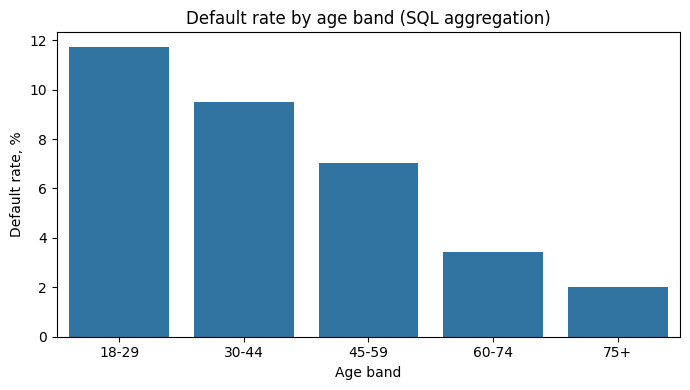

In [28]:
default_rate_query["default_rate_pct"] = default_rate_query["default_rate"] * 100

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=default_rate_query, x="age_band", y="default_rate_pct", ax=ax)
ax.set_title("Default rate by age band (SQL aggregation)")
ax.set_ylabel("Default rate, %")
ax.set_xlabel("Age band")
plt.tight_layout()
plt.show()

**Вывод**: чем старше заёмщик, тем реже он уходит в дефолт. У самых молодых (18–29 лет) дефолт случается в 11.7% случаев, а у самых старших (75+) — только в 2.0%. То есть молодые попадают в дефолт почти в 6 раз чаще. Значит, уже по одному возрасту видно, что это важный признак риска — ещё до того, как мы построим модель.

# EDA

In [48]:
df = pd.read_sql("SELECT * FROM borrowers", conn, index_col="borrower_id")

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [50]:
missing = pd.DataFrame({"count": df.isna().sum(),"percent": df.isna().mean() * 100})

missing

,count,percent
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
MonthlyIncome,29731,19.820667
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## Удаление аномальной записи (age=0)

Проверили запись с `age=0` вручную - независимо от значений остальных
признаков, возраст 0 физически недостоверен. Это единственная такая строка
из 150 000, поэтому удаление не повлияет на статистику модели - удаляем.

In [52]:
df = df[df["age"] > 0]

## Пропуски в MonthlyIncome
Около 20% значений пропущено. Удалять столько строк нельзя, поэтому заполняем пропуски медианой. Она лучше среднего подходит для дохода, потому что меньше зависит от больших значений и выбросов. Дополнительно создадим отдельный признак, показывающий, что доход был пропущен - возможно, сам факт отсутствия этой информации связан с риском дефолта.


In [53]:
df["MonthlyIncome_was_missing"] = df["MonthlyIncome"].isna().astype(int)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

### Пропуски в NumberOfDependents

Около 2.6% значений пропущено. Сначала проверим, отличается ли уровень дефолтов у клиентов с пропущенным значением от клиентов, у которых число иждивенцев указано. Если разница небольшая, для простоты заменим пропуски на 0.


In [54]:
print("Пропущено:", df[df["NumberOfDependents"].isna()]["SeriousDlqin2yrs"].mean())
print("Не пропущено:", df[df["NumberOfDependents"].notna()]["SeriousDlqin2yrs"].mean())

Пропущено: 0.04561671763506626
Не пропущено: 0.06741057675851446


Проверим, связан ли сам факт пропуска с дефолтом.

Гипотезы:

* H0: наличие пропуска в NumberOfDependents не связано с дефолтом.
* H1: наличие пропуска в NumberOfDependents связано с дефолтом.

Для проверки используем χ²-тест независимости.

In [58]:
temp_t = pd.crosstab(
    df["NumberOfDependents"].isna(),
    df["SeriousDlqin2yrs"]
)
temp_t

SeriousDlqin2yrs,0,1
NumberOfDependents,,
False,136228,9847
True,3745,179


In [59]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(temp_t)

print("chi2:", chi2)
print("p-value:", p_value)

chi2: 28.75140658613835
p-value: 8.229013222139592e-08


Получили:

* χ² = 28.75
* p-value = 8.23 × 10⁻⁸

Так как p-value значительно меньше 0.05, отвергаем H0. Значит, в наших данных есть статистически значимая связь между наличием пропуска в NumberOfDependents и дефолтом.

Поэтому не будем просто терять информацию о пропуске: заменим NaN на 0 и дополнительно создадим отдельный признак, показывающий, было ли значение пропущено.

In [61]:
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isna().astype(int)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149999.0,6.048472,249.756203,0.0,0.029867,0.154176,0.559044,50708.0
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149999.0,0.421029,4.192795,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,149999.0,353.007426,2037.825113,0.0,0.175074,0.366503,0.868257,329664.0
MonthlyIncome,149999.0,6418.457710,12890.438465,0.0,3903.000000,5400.000000,7400.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149999.0,0.265975,4.169318,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149999.0,0.240388,4.155193,0.0,0.000000,0.000000,0.000000,98.0


# RevolvingUtilizationOfUnsecuredLines

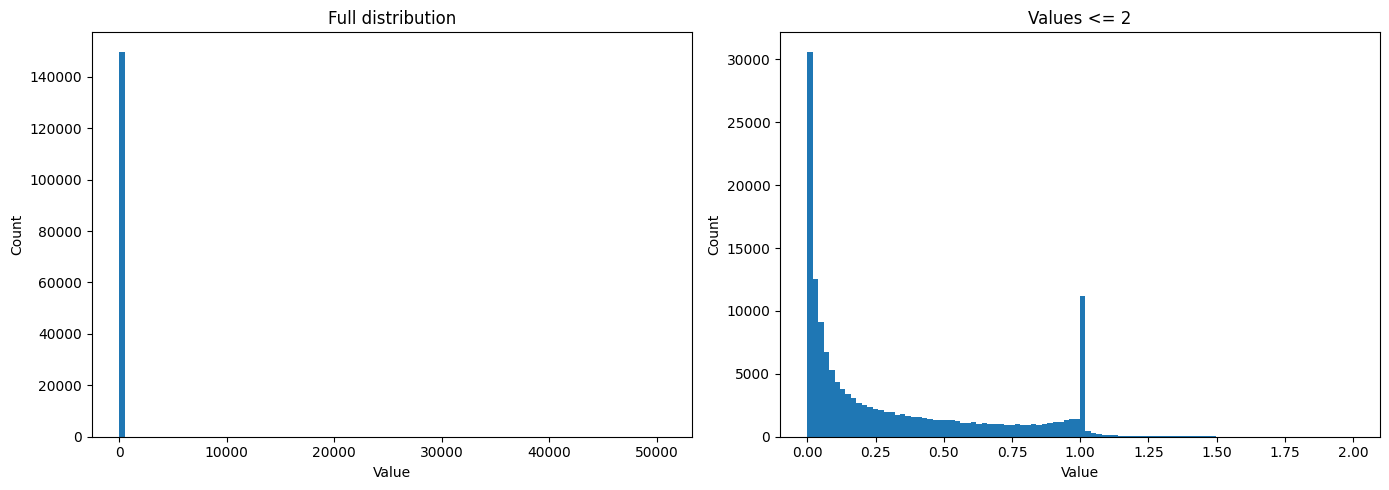

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Полное распределение
axes[0].hist(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=100
)
axes[0].set_title("Full distribution")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Основная масса значений
axes[1].hist(
    df.loc[
        df["RevolvingUtilizationOfUnsecuredLines"] <= 2,
        "RevolvingUtilizationOfUnsecuredLines"
    ],
    bins=100
)
axes[1].set_title("Values <= 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [77]:
#Проверяем, какая доля наблюдений находится в хвосте
for threshold in [1, 2, 5, 10, 100]:
    count = (df["RevolvingUtilizationOfUnsecuredLines"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

df["RevolvingUtilizationOfUnsecuredLines"].quantile(
    [0.95, 0.99, 0.995, 0.999]
)

>1: 3321 (2.21%)
>2: 371 (0.25%)
>5: 254 (0.17%)
>10: 241 (0.16%)
>100: 223 (0.15%)


,RevolvingUtilizationOfUnsecuredLines
0.950,1.000000
0.990,1.092958
0.995,1.366279
0.999,1571.012000


In [78]:
#Отдельно смотрим только значения выше 1
df.loc[
    df["RevolvingUtilizationOfUnsecuredLines"] > 1,
    "RevolvingUtilizationOfUnsecuredLines"
].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).T

,RevolvingUtilizationOfUnsecuredLines
count,3321.000000
mean,259.773362
std,1659.034074
min,1.000059
50%,1.074633
90%,2.197674
95%,1090.000000
99%,6723.000000
99.9%,21524.480000
max,50708.000000


In [79]:
#Разбиваем значения на несколько диапазонов и сравниваем их с default rate
df["util_group"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-float("inf"), 1, 2, 10, 100, float("inf")],
    labels=["<=1", "1-2", "2-10", "10-100", ">100"]
)

df.groupby("util_group", observed=True)["SeriousDlqin2yrs"].agg(
    ["count", "mean"]
)

,count,mean
util_group,,
<=1,146678,0.059920
1-2,2950,0.401017
2-10,130,0.284615
10-100,18,0.333333
>100,223,0.049327


In [81]:
import numpy as np
# Сильно скошенные значения сжимаем логарифмом, диагностический столбец больше не нужен
df["RevolvingUtilization_log"] = np.log1p(
    df["RevolvingUtilizationOfUnsecuredLines"]
)
df.drop(columns="util_group", inplace=True)

# AGE

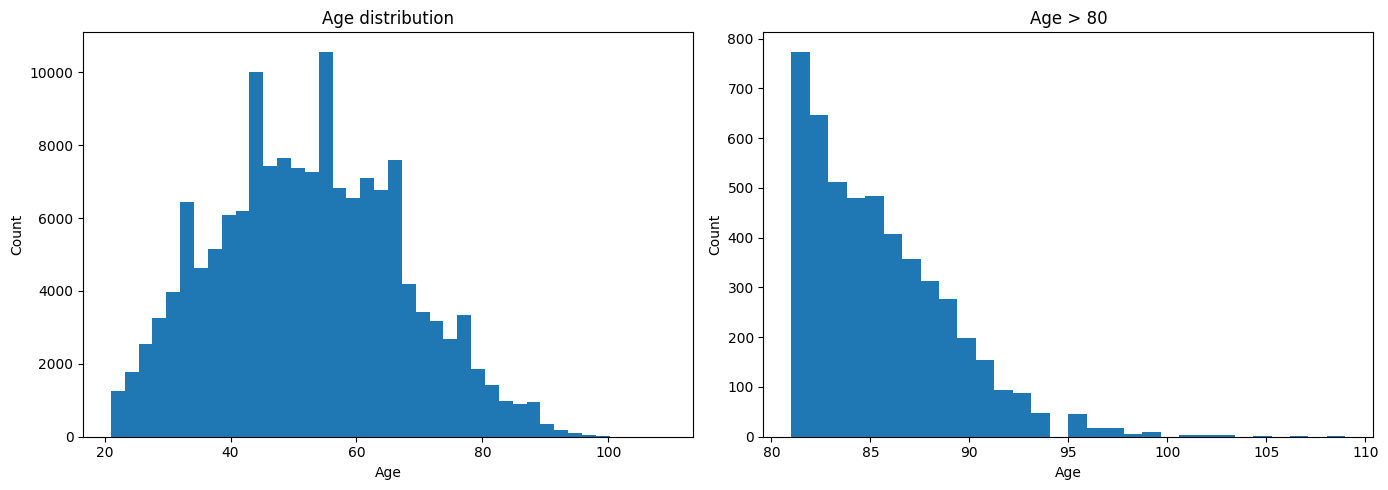

In [82]:
#Смотрим распределение возраста и проверяем крайние значения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=40)
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["age"] > 80, "age"],
    bins=30
)
axes[1].set_title("Age > 80")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [83]:
print("Age > 100:", (df["age"] > 100).sum())
print("Maximum age:", df["age"].max())

Age > 100: 13
Maximum age: 109


# NumberOfTime30-59DaysPastDueNotWorse

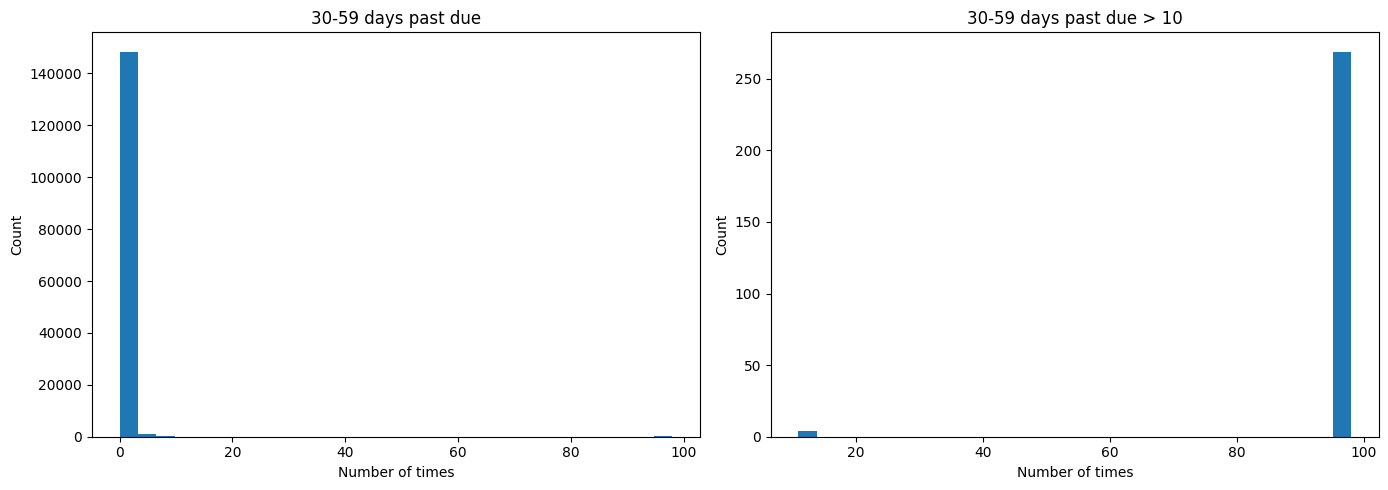

In [84]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(
    df["NumberOfTime30-59DaysPastDueNotWorse"],
    bins=30
)
axes[0].set_title("30-59 days past due")
axes[0].set_xlabel("Number of times")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[
        df["NumberOfTime30-59DaysPastDueNotWorse"] > 10,
        "NumberOfTime30-59DaysPastDueNotWorse"
    ],
    bins=30
)
axes[1].set_title("30-59 days past due > 10")
axes[1].set_xlabel("Number of times")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [85]:
#Проверяем самые частые значения и подозрительное значение 98
print(
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    .value_counts()
    .sort_index()
    .tail(15)
)

NumberOfTime30-59DaysPastDueNotWorse
1     16032
2      4598
3      1754
4       747
5       342
6       140
7        54
8        25
9        12
10        4
11        1
12        2
13        1
96        5
98      264
Name: count, dtype: int64


In [87]:
#Проверяем три признака просрочек: в них встречаются одинаковые аномальные значения
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_cols:
    print(
        col,
        "96:", (df[col] == 96).sum(),
        "98:", (df[col] == 98).sum()
    )

NumberOfTime30-59DaysPastDueNotWorse 96: 5 98: 264
NumberOfTime60-89DaysPastDueNotWorse 96: 5 98: 264
NumberOfTimes90DaysLate 96: 5 98: 264


In [88]:
#Обрабатываем одинаковые аномальные значения во всех признаках просрочек
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_cols:
    #Сохраняем информацию о наличии аномального значения
    df[col + "_missing"] = df[col].isin([96, 98]).astype(int)

    #Заменяем аномальные значения на пропуски
    df[col] = df[col].replace([96, 98], np.nan)

    #Для количества просрочек используем 0 как простое значение после очистки
    df[col] = df[col].fillna(0)

In [89]:
# Проверяем, что аномальных значений больше нет
for col in delinq_cols:
    print(col, "96:", (df[col] == 96).sum(), "98:", (df[col] == 98).sum())

NumberOfTime30-59DaysPastDueNotWorse 96: 0 98: 0
NumberOfTime60-89DaysPastDueNotWorse 96: 0 98: 0
NumberOfTimes90DaysLate 96: 0 98: 0


### Признаки просрочек

В трёх признаках просрочек обнаружены аномальные значения 96 и 98. Они заменены на пропуски, при этом добавлен отдельный индикатор их наличия. После этого пропуски заполнены значением 0.


# DebtRatio

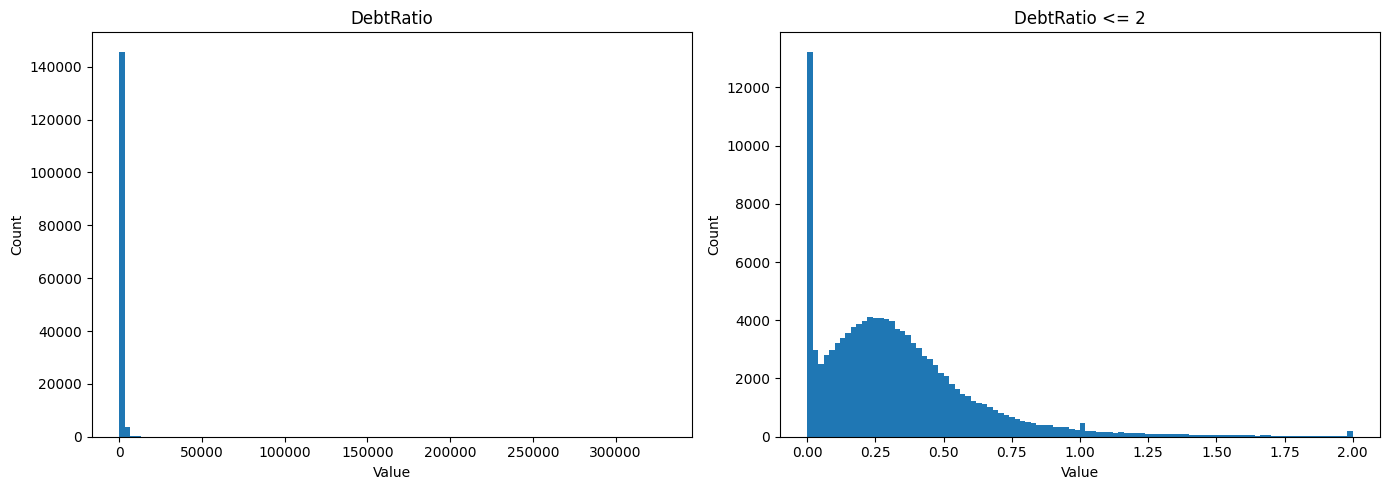

In [90]:
#Проверяем распределение DebtRatio и его длинный хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["DebtRatio"],
    bins=100
)
axes[0].set_title("DebtRatio")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["DebtRatio"] <= 2, "DebtRatio"],
    bins=100
)
axes[1].set_title("DebtRatio <= 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [91]:
#Проверяем, насколько много экстремальных значений
for threshold in [1, 2, 5, 10, 100]:
    count = (df["DebtRatio"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

>1: 35137 (23.42%)
>2: 31045 (20.70%)
>5: 29646 (19.76%)
>10: 28877 (19.25%)
>100: 24380 (16.25%)


In [92]:
#DebtRatio имеет очень длинный правый хвост, поэтому добавляем лог-преобразование
df["DebtRatio_log"] = np.log1p(df["DebtRatio"])

In [93]:
#Проверяем распределение после лог-преобразования
df["DebtRatio_log"].describe()

,DebtRatio_log
count,149999.000000
mean,1.525182
std,2.627244
min,0.000000
25%,0.161331
50%,0.312255
75%,0.625006
max,12.705832



`DebtRatio` имеет сильно скошенное распределение и длинный правый хвост. Значения напрямую не удаляли, так как они занимают значительную долю выборки. Для уменьшения влияния экстремальных значений добавили логарифмическое преобразование `DebtRatio_log`.


# MonthlyIncome

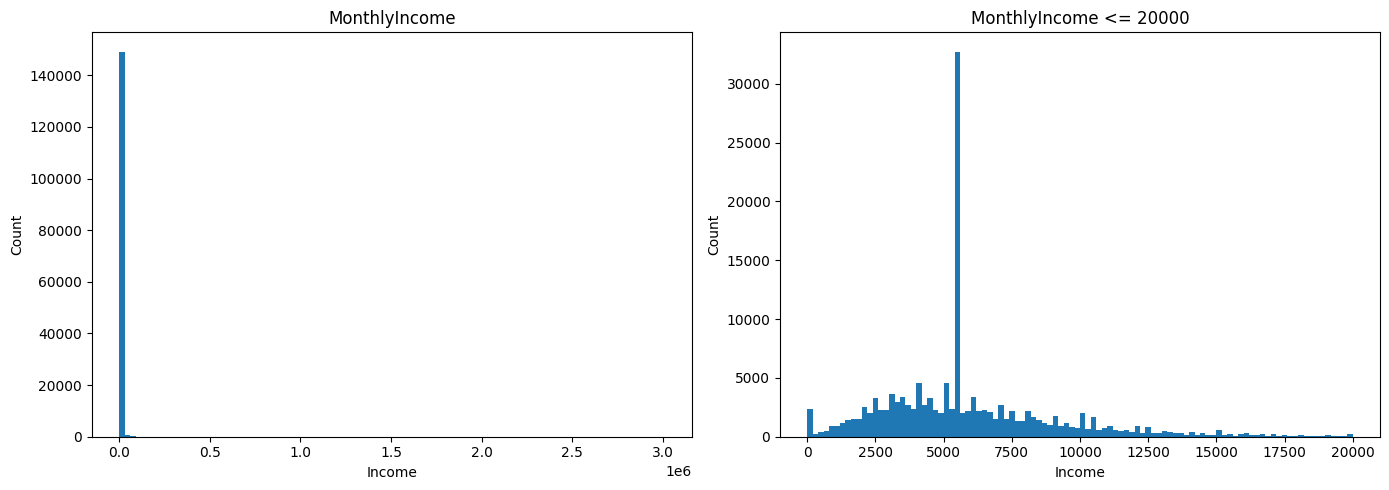

>10000: 18319 (12.21%)
>20000: 2103 (1.40%)
>50000: 301 (0.20%)
>100000: 70 (0.05%)


In [94]:
#Смотрим распределение дохода и его длинный хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["MonthlyIncome"],
    bins=100
)
axes[0].set_title("MonthlyIncome")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["MonthlyIncome"] <= 20000, "MonthlyIncome"],
    bins=100
)
axes[1].set_title("MonthlyIncome <= 20000")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост дохода
for threshold in [10000, 20000, 50000, 100000]:
    count = (df["MonthlyIncome"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

In [95]:
#Доход имеет правый хвост, поэтому добавляем логарифмическую версию признака
df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])

In [96]:
#Проверяем распределение после лог-преобразования
df["MonthlyIncome_log"].describe()

,MonthlyIncome_log
count,149999.000000
mean,8.447403
std,1.195800
min,0.000000
25%,8.269757
50%,8.594339
75%,8.909370
max,14.917036


В `MonthlyIncome` наблюдается выраженный правый хвост. После логарифмического преобразования распределение стало значительно более компактным. Исходный признак оставили, а также добавили `MonthlyIncome_log` для моделей, чувствительных к масштабу и выбросам.


# NumberOfOpenCreditLinesAndLoans

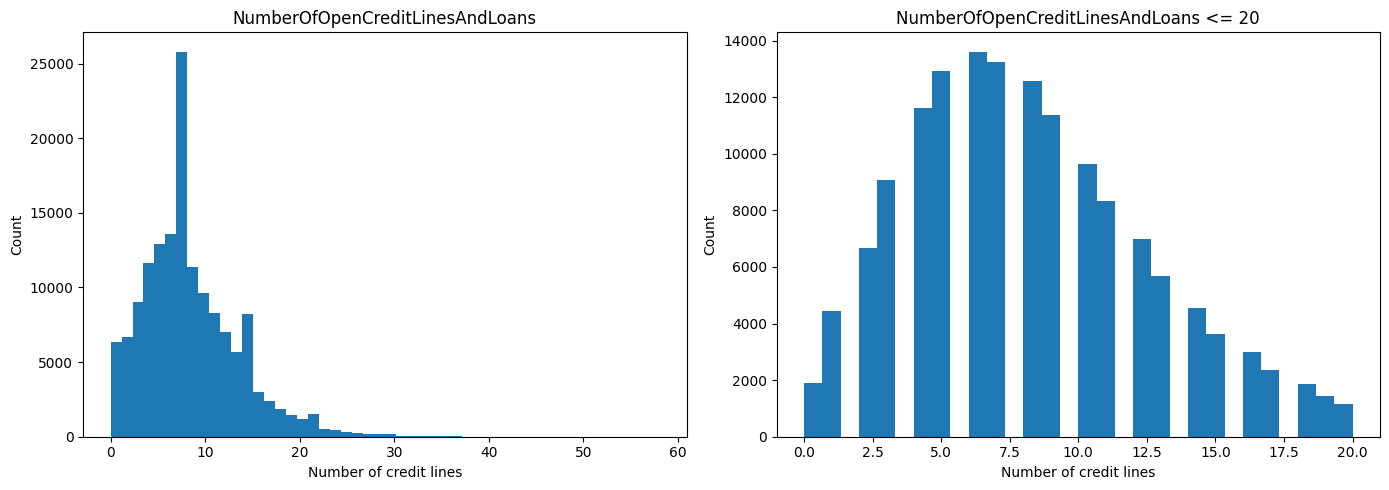

>10: 43010 (28.67%)
>20: 3980 (2.65%)
>30: 354 (0.24%)
>40: 62 (0.04%)
>50: 15 (0.01%)


In [97]:
#Смотрим распределение количества открытых кредитных линий и его хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["NumberOfOpenCreditLinesAndLoans"],
    bins=50
)

axes[0].set_title("NumberOfOpenCreditLinesAndLoans")
axes[0].set_xlabel("Number of credit lines")
axes[0].set_ylabel("Count")


axes[1].hist(
    df.loc[
        df["NumberOfOpenCreditLinesAndLoans"] <= 20,
        "NumberOfOpenCreditLinesAndLoans"
    ],
    bins=30
)

axes[1].set_title("NumberOfOpenCreditLinesAndLoans <= 20")
axes[1].set_xlabel("Number of credit lines")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост
for threshold in [10, 20, 30, 40, 50]:

    count = (
        df["NumberOfOpenCreditLinesAndLoans"] > threshold
    ).sum()

    percent = count / len(df) * 100

    print(f">{threshold}: {count} ({percent:.2f}%)")

Признак имеет правый хвост, однако экстремальные значения встречаются редко: только 0.24% наблюдений имеют более 30 открытых кредитных линий. Оснований считать значения аномальными нет, поэтому признак оставили без изменений.

# NumberRealEstateLoansOrLines

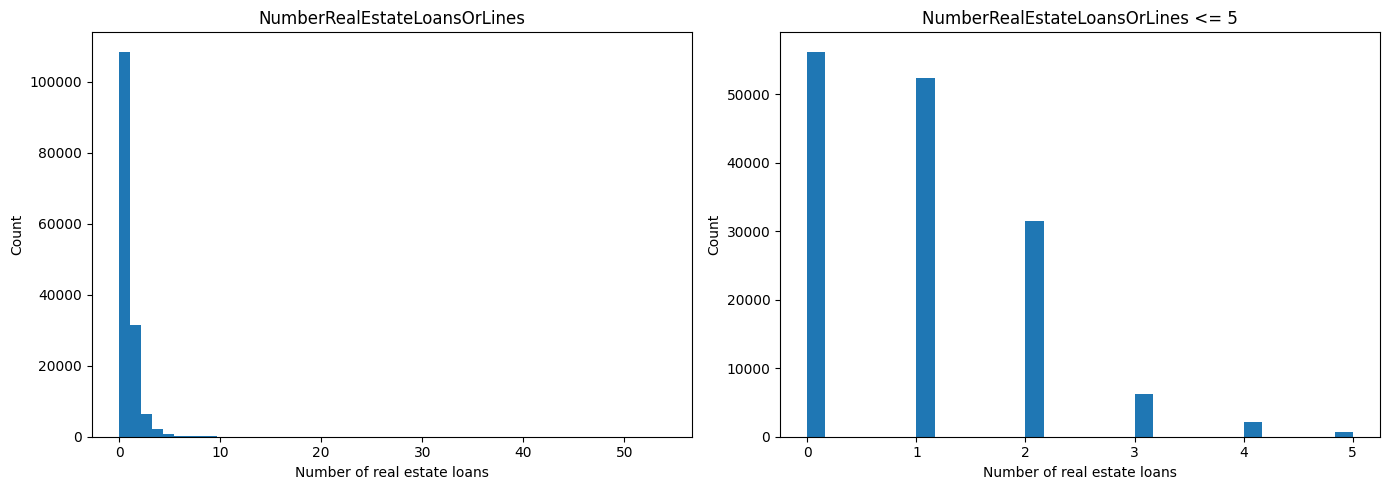

>2: 9952 (6.63%)
>5: 793 (0.53%)
>10: 94 (0.06%)
>20: 10 (0.01%)
>30: 2 (0.00%)


In [98]:
# Смотрим распределение количества ипотечных и других кредитов, связанных с недвижимостью
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["NumberRealEstateLoansOrLines"],
    bins=50
)

axes[0].set_title("NumberRealEstateLoansOrLines")
axes[0].set_xlabel("Number of real estate loans")
axes[0].set_ylabel("Count")


axes[1].hist(
    df.loc[
        df["NumberRealEstateLoansOrLines"] <= 5,
        "NumberRealEstateLoansOrLines"
    ],
    bins=30
)

axes[1].set_title("NumberRealEstateLoansOrLines <= 5")
axes[1].set_xlabel("Number of real estate loans")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост
for threshold in [2, 5, 10, 20, 30]:

    count = (
        df["NumberRealEstateLoansOrLines"] > threshold
    ).sum()

    percent = count / len(df) * 100

    print(f">{threshold}: {count} ({percent:.2f}%)")

Признак имеет небольшой правый хвост, но экстремальные значения встречаются крайне редко. Значения свыше 10 наблюдаются только в 0.06% случаев, поэтому оснований считать их аномальными нет. Признак оставили без изменений.

# Финальная проверка качества данных

In [101]:
print("Размер датасета:", df.shape)

print("\nПропуски:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nКоличество пропусков всего:", df.isna().sum().sum())

print("\nТипы данных:")
print(df.dtypes)

print("\nЦелевой признак:")
print(df["SeriousDlqin2yrs"].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True))

print("\nДиапазоны числовых признаков:")
print(df.describe().T[["min", "max"]])

Размер датасета: (149999, 19)

Пропуски:
Series([], dtype: int64)

Количество пропусков всего: 0

Типы данных:
SeriousDlqin2yrs                                  int64
RevolvingUtilizationOfUnsecuredLines            float64
age                                               int64
NumberOfTime30-59DaysPastDueNotWorse            float64
DebtRatio                                       float64
MonthlyIncome                                   float64
NumberOfOpenCreditLinesAndLoans                   int64
NumberOfTimes90DaysLate                         float64
NumberRealEstateLoansOrLines                      int64
NumberOfTime60-89DaysPastDueNotWorse            float64
NumberOfDependents                              float64
MonthlyIncome_was_missing                         int64
NumberOfDependents_missing                        int64
RevolvingUtilization_log                        float64
NumberOfTime30-59DaysPastDueNotWorse_missing      int64
NumberOfTime60-89DaysPastDueNotWorse_missing     

После проведения EDA и preprocessing датасет подготовлен к моделированию. Пропуски обработаны, аномальные значения в признаках просрочек скорректированы с сохранением индикаторов, для сильно скошенных признаков добавлены логарифмические версии.

Редкие экстремальные значения в остальных признаках не удалялись без достаточных оснований. Диагностические признаки после анализа удалены.

В итоговом датасете 149 999 наблюдений и 19 признаков, пропуски отсутствуют. Доля положительного класса `SeriousDlqin2yrs` составляет 6.68%.


# Смотрим корреляции

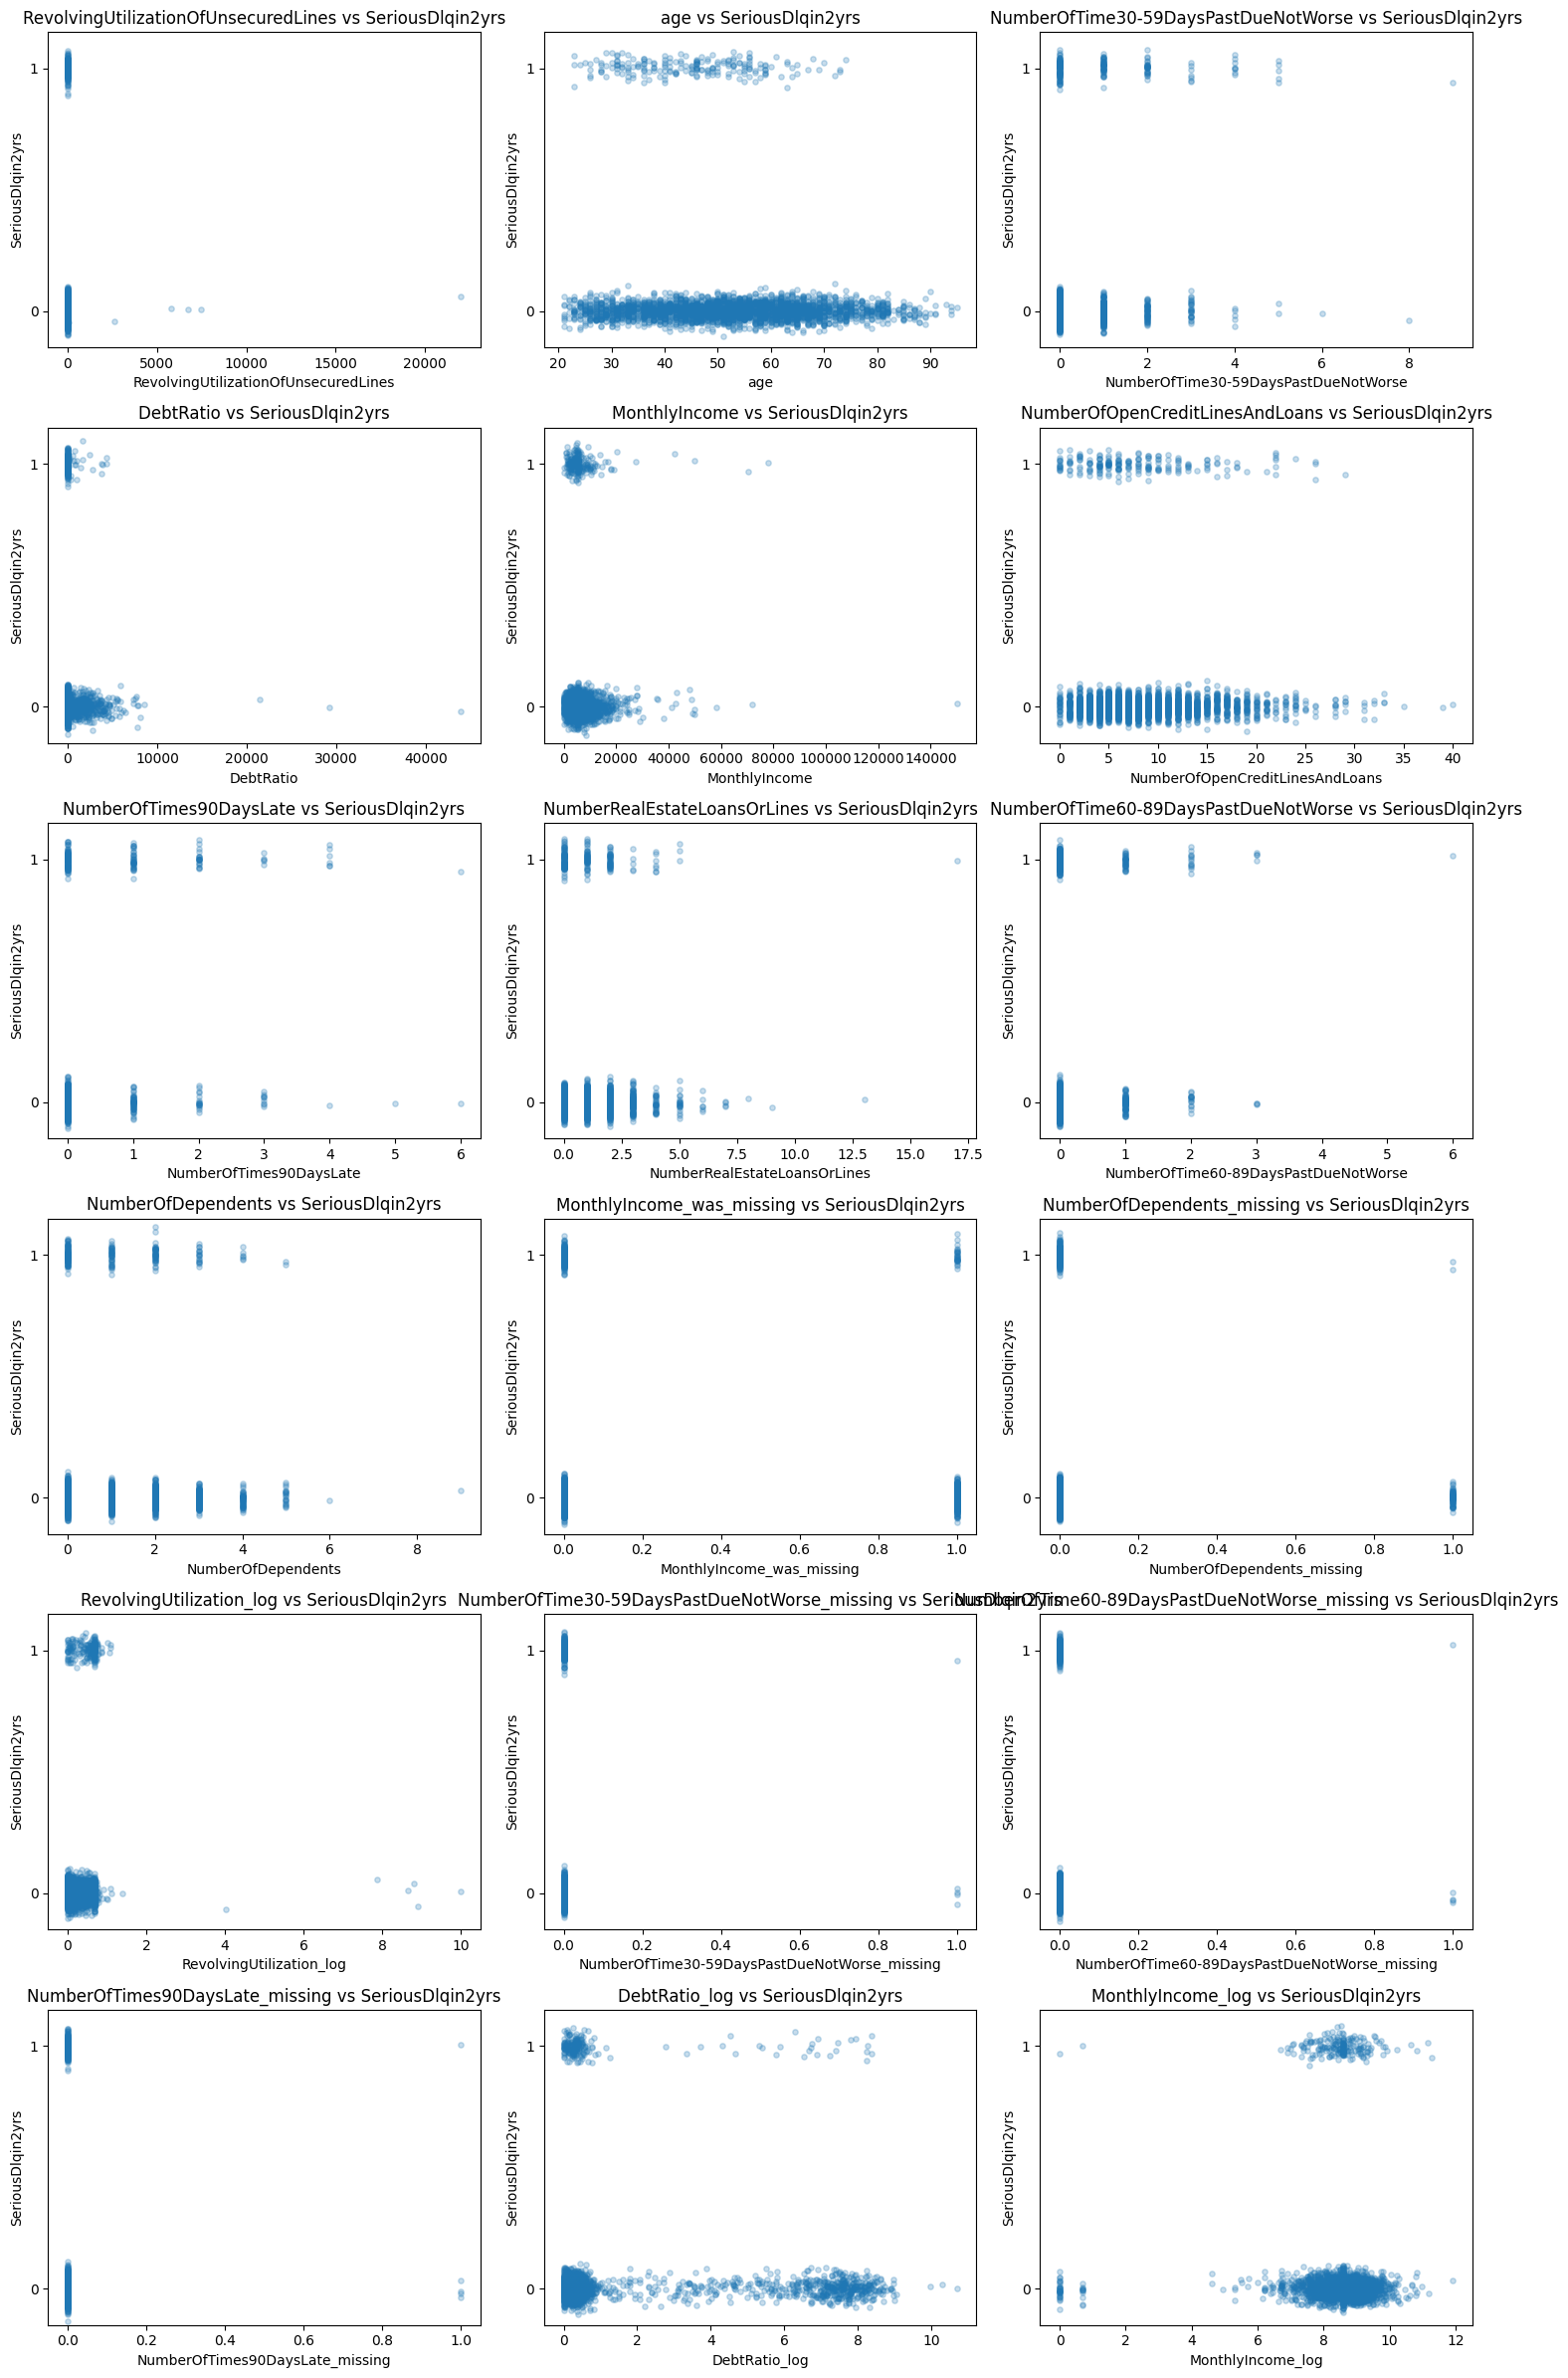

In [107]:
import seaborn as sns
def plot_feature_scatter(df: pd.DataFrame, target: str, sample_size: int = 3000):
    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    numeric_features = df.select_dtypes(include="number").columns.drop(
        target, errors="ignore"
    )

    n_features = len(numeric_features)
    ncols = 3
    nrows = (n_features + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4 * nrows)
    )

    axes = axes.flatten()

    for i, feature in enumerate(numeric_features):
        y_jitter = df[target] + np.random.normal(
            0, 0.03, size=len(df)
        )

        axes[i].scatter(
            df[feature],
            y_jitter,
            alpha=0.25,
            s=15
        )

        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target)
        axes[i].set_title(f"{feature} vs {target}")

        axes[i].set_yticks([0, 1])
        axes[i].set_ylim(-0.15, 1.15)

    for ax in axes[n_features:]:
        ax.remove()

    plt.tight_layout()
    plt.show()


plot_feature_scatter(df, "SeriousDlqin2yrs", 3000)

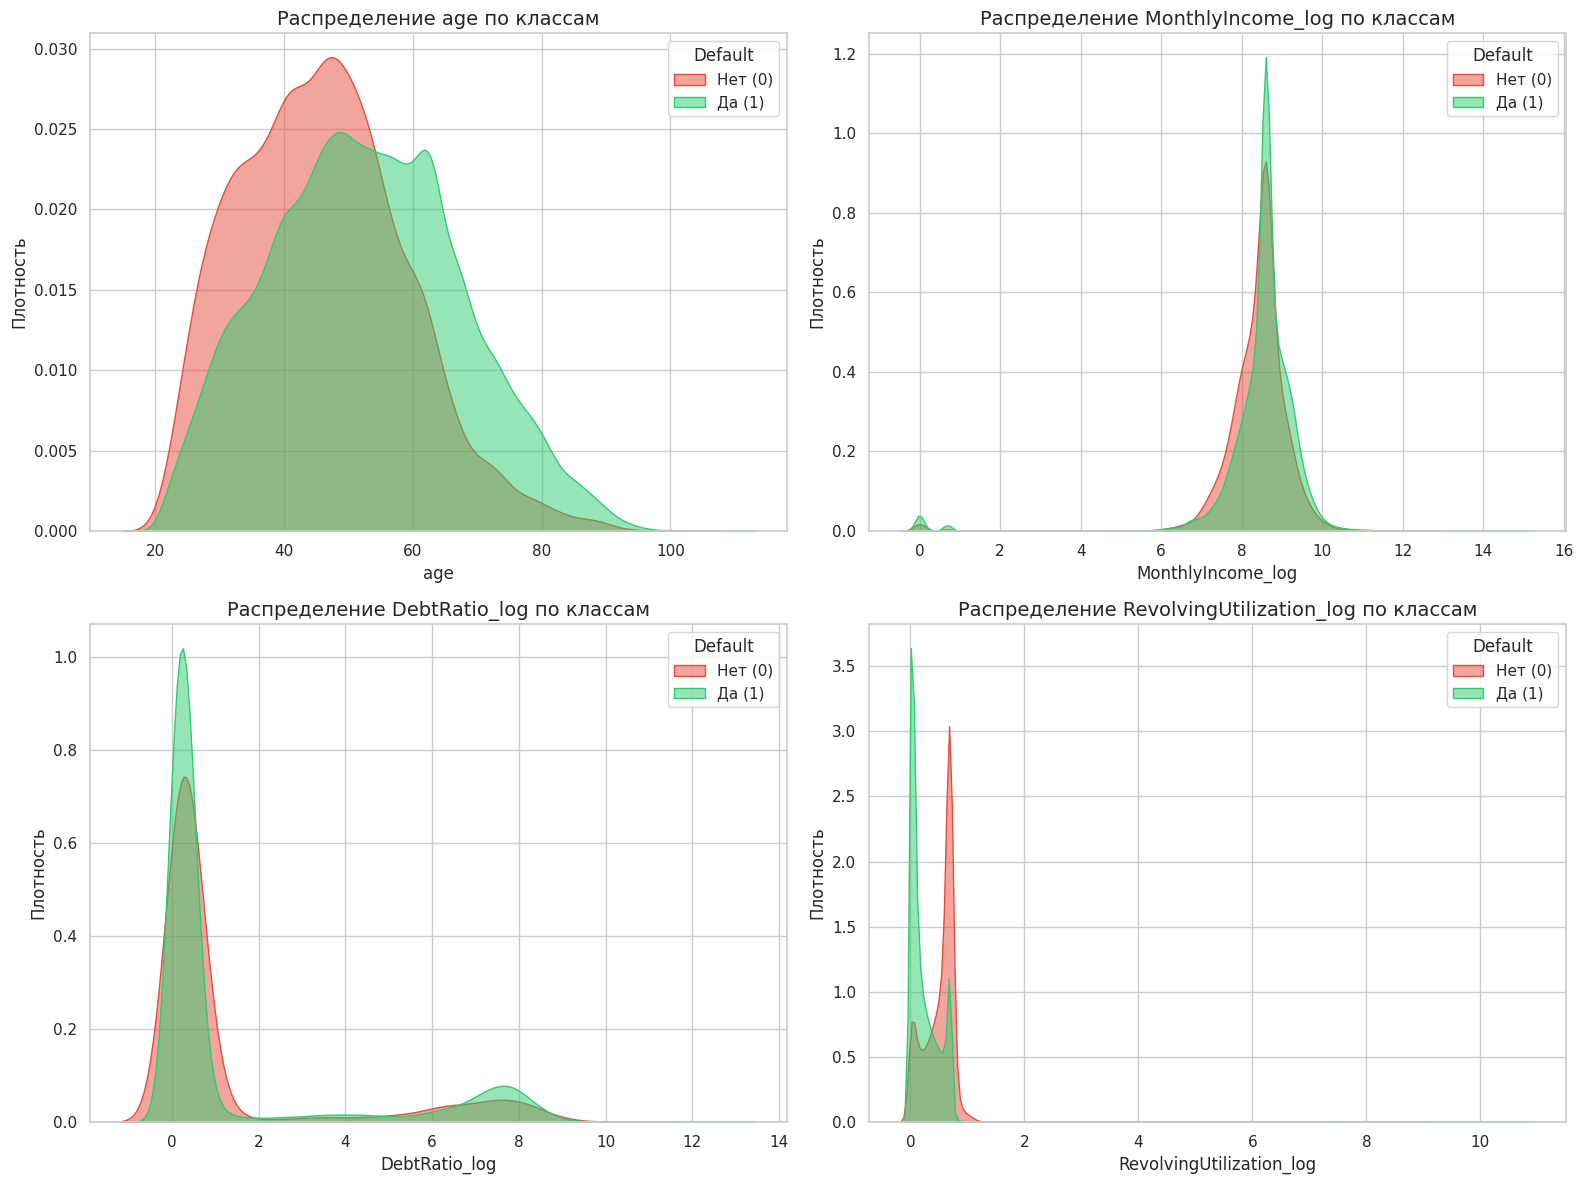

In [108]:
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

target = 'SeriousDlqin2yrs'

continuous_features = [
    'age',
    'MonthlyIncome_log',
    'DebtRatio_log',
    'RevolvingUtilization_log'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.kdeplot(
        data=df, x=col, hue=target,
        fill=True, common_norm=False,
        palette=['#2ecc71', '#e74c3c'], # Зеленый для 0, Красный для 1
        alpha=0.5, ax=axes[i]
    )
    axes[i].set_title(f'Распределение {col} по классам', fontsize=14)
    axes[i].set_ylabel('Плотность')
    axes[i].legend(title='Default', labels=['Нет (0)', 'Да (1)'])

plt.tight_layout()
plt.show()

interval columns not set, guessing: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'RevolvingUtilization_log', 'DebtRatio_log', 'MonthlyIncome_log', 'SeriousDlqin2yrs']


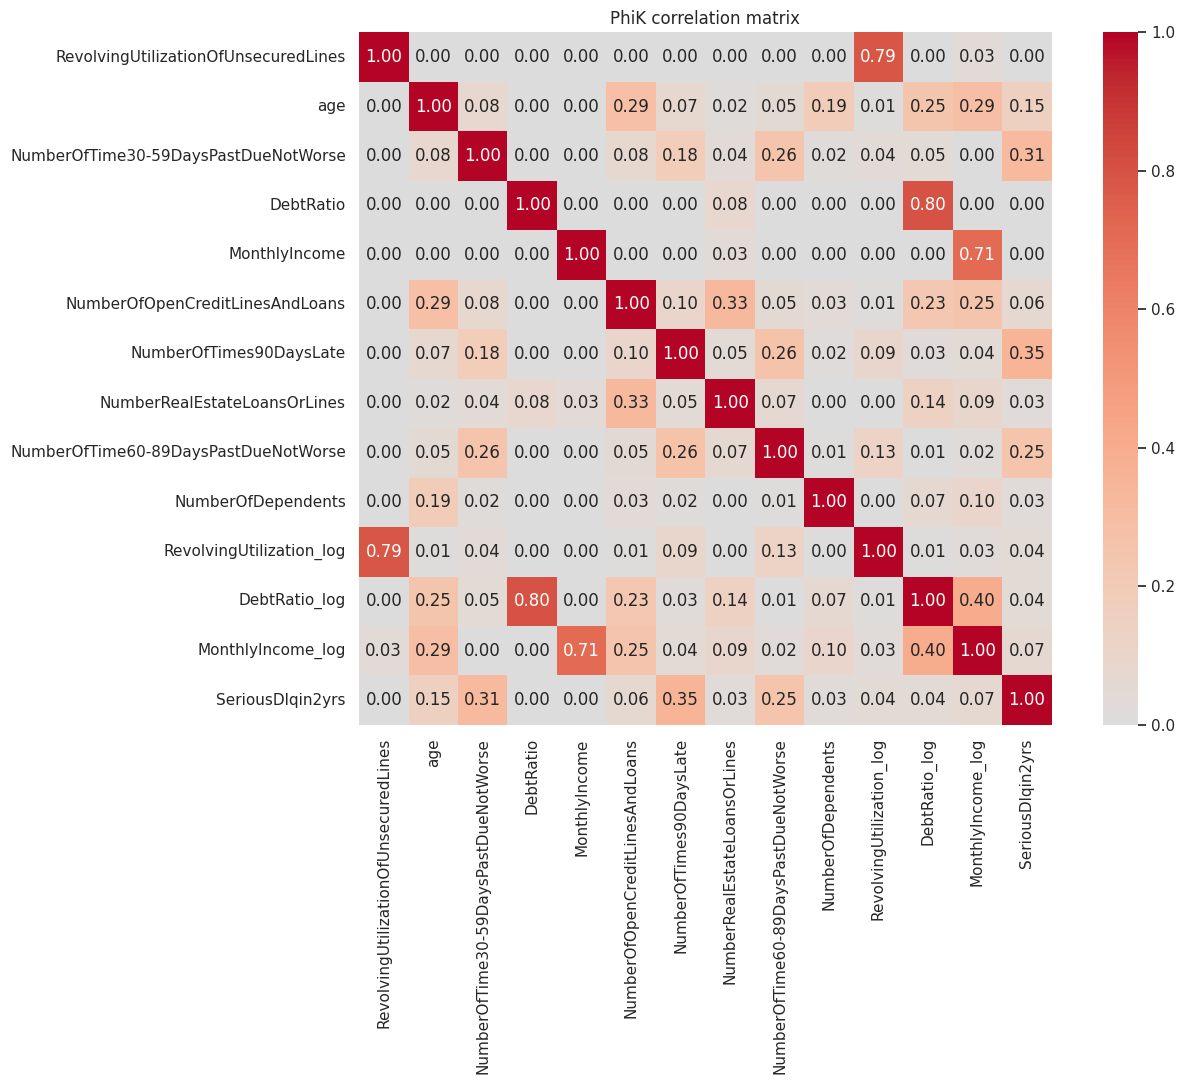

In [112]:
import phik

phik_matrix = df[plot_cols + ["SeriousDlqin2yrs"]].phik_matrix()

plt.figure(figsize=(14, 11))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("PhiK correlation matrix")
plt.tight_layout()
plt.show()

## Общий вывод по EDA

* **Scatter plots:** из-за бинарного таргета наблюдается overplotting. Видны выбросы в `DebtRatio`, `RevolvingUtilization` и `MonthlyIncome`. Признаки просрочек наиболее заметно разделяют классы.
* **KDE:** `RevolvingUtilization_log` показывает выраженную нелинейную связь с дефолтом. `MonthlyIncome_log` - слабый одиночный признак. `DebtRatio_log` сохраняет длинный хвост.
* **PhiK:** наиболее сильная связь с таргетом у признаков просрочек: `90DaysLate` - 0.35, `30-59DaysLate` - 0.31, `60-89DaysLate` - 0.25. Исходные признаки и их log-версии имеют высокую взаимную зависимость (0.71–0.80)


# Деление данных и создание фич

In [113]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Default rate train:", y_train.mean())
print("Default rate test:", y_test.mean())

Train: (119999, 18)
Test: (30000, 18)
Default rate train: 0.06684222368519738
Default rate test: 0.06683333333333333


In [122]:
from pycaret.classification import ClassificationExperiment

train = X_train.copy()
train["SeriousDlqin2yrs"] = y_train

exp = ClassificationExperiment(
    target="SeriousDlqin2yrs",
    session_id=42,
    train_size=0.8,
    fold_strategy='stratifiedkfold',
    fold=5,
    verbose=True
).fit(train)

selected_models = [
    "lr", "dt", "rf", "et", "gbc", "xgboost", "lightgbm", "catboost"
]

best_model = exp.compare_models(
    include=selected_models,
    sort="AUC"
)

[LightGBM] [Info] Number of positive: 5134, number of negative: 71665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1736
[LightGBM] [Info] Number of data points in the train set: 76799, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066850 -> initscore=-2.636117
[LightGBM] [Info] Start training from score -2.636117
[LightGBM] [Info] Number of positive: 5134, number of negative: 71665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1736
[LightGBM] [Info] Number of data points in the train set: 76799, number of used features: 18
[LightGBM] [Info] [b

In [126]:
results = exp.pull()
results = results.sort_values('AUC', ascending=False).reset_index(drop=True)
results.style.background_gradient(cmap='RdYlGn', subset=['AUC'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,gbc,0.936900,0.861500,0.185000,0.591000,0.281500,0.257900,0.306600
1,lightgbm,0.936900,0.861200,0.185000,0.590500,0.281500,0.257800,0.306400
2,catboost,0.936100,0.861000,0.192100,0.564300,0.286600,0.261500,0.303900
3,xgboost,0.934700,0.849500,0.198100,0.531800,0.288300,0.261600,0.297300
4,rf,0.935400,0.839000,0.176100,0.554100,0.267200,0.242700,0.287300
5,et,0.934600,0.832800,0.169700,0.535500,0.257600,0.232900,0.275900
6,lr,0.936100,0.830300,0.170500,0.573500,0.262700,0.239400,0.288800
7,dt,0.897300,0.611700,0.280800,0.255500,0.267500,0.212400,0.212700


Бустинги дали ROC-AUC около 0.86, логистическая регрессия — 0.83.

При стандартном пороге 0.5 модель ловит только 19% дефолтов. Для кредитного скоринга это неприемлемо — мы пропускаем 4 из 5 плохих заёмщиков.